# 📊 ĐÁNH GIÁ HIỆU NĂNG MONTE CARLO
## Xử lý Tín hiệu Số

---

**Họ và tên:** Trần Lê Phi Long
**MSSV:** 102240092
**Phần phụ trách:** Đánh giá hiệu năng Monte Carlo — Tỷ lệ phát hiện đúng (Detection Rate) và Sai số RMSE theo SNR (Bước 3)

---

## 🎯 Mục tiêu

Khảo sát thống kê hiệu năng ước lượng độ trễ qua **31 mức SNR (từ $-15\text{ dB}$ đến $+15\text{ dB}$) $\times 100\text{ lần thử}$**:

1. **Tỷ lệ phát hiện đúng (Detection Rate - DR):** Tỷ lệ phần trăm các lần thử có sai số ước lượng nằm trong dung sai cho phép $\le 2.0\text{ ms}$ ($16\text{ mẫu}$ tại $f_s = 8000\text{ Hz}$).
2. **Sai số toàn phương trung bình (RMSE):** Đánh giá độ lệch trung bình của độ trễ ước lượng $\hat{D}$ so với độ trễ thực $D$.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time

# Thiết lập phong cách hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.autolayout': True,
})

# Tham số hệ thống
FS = 8000                  # Tần số lấy mẫu (Hz)
M = 50                     # Độ dài xung phát (mẫu)
D_TRUE = 200               # Độ trễ thực tế (mẫu)
N_TOTAL = 1000             # Tổng số mẫu tín hiệu thu
K_RUNS = 100               # Số lần thử Monte Carlo cho mỗi mức SNR
TOLERANCE_MS = 2.0         # Dung sai phát hiện đúng (ms)
TOLERANCE_SAMPLES = int(round(TOLERANCE_MS * FS / 1000.0))  # 16 mẫu
SNR_DBS = np.arange(-15, 16, 1)  # 31 mức SNR từ -15 dB đến +15 dB

print('=' * 65)
print('  HỆ THỐNG THAM SỐ MÔ PHỎNG MONTE CARLO')
print('=' * 65)
print(f'• Tần số lấy mẫu (fs)        : {FS} Hz (Chu kỳ Ts = {1000/FS:.3f} ms)')
print(f'• Độ dài xung phát (M)       : {M} mẫu ({M*1000/FS:.2f} ms)')
print(f'• Độ trễ thực tế (D)         : {D_TRUE} mẫu ({D_TRUE*1000/FS:.2f} ms)')
print(f'• Chiều dài tín hiệu thu (N) : {N_TOTAL} mẫu ({N_TOTAL*1000/FS:.2f} ms)')
print(f'• Dung sai phát hiện đúng    : ≤ {TOLERANCE_MS} ms ({TOLERANCE_SAMPLES} mẫu)')
print(f'• Số lần thử nghiệm (K)      : {K_RUNS} lần / mức SNR')
print(f'• Dải SNR khảo sát           : {SNR_DBS[0]} dB đến {SNR_DBS[-1]} dB (Tổng {len(SNR_DBS)} mức)')
print('=' * 65)


  HỆ THỐNG THAM SỐ MÔ PHỎNG MONTE CARLO
• Tần số lấy mẫu (fs)        : 8000 Hz (Chu kỳ Ts = 0.125 ms)
• Độ dài xung phát (M)       : 50 mẫu (6.25 ms)
• Độ trễ thực tế (D)         : 200 mẫu (25.00 ms)
• Chiều dài tín hiệu thu (N) : 1000 mẫu (125.00 ms)
• Dung sai phát hiện đúng    : ≤ 2.0 ms (16 mẫu)
• Số lần thử nghiệm (K)      : 100 lần / mức SNR
• Dải SNR khảo sát           : -15 dB đến 15 dB (Tổng 31 mức)


In [18]:
def generate_triangle_pulse(length: int, amplitude: float = 1.0):
    """
    Tạo xung tam giác đối xứng s[n] có đỉnh = amplitude tại tâm xung.
    (Đồng bộ hoàn toàn thuật toán với SV1).
    """
    pulse = np.zeros(length, dtype=float)
    center = (length - 1) / 2.0
    for n in range(length):
        if center > 0:
            val = amplitude * (1.0 - abs(n - center) / center)
            pulse[n] = max(0.0, val)
        else:
            pulse[n] = amplitude
    return pulse

def create_received_signal(pulse, delay: int, total_len: int):
    """
    Tạo tín hiệu thu lý tưởng r_clean[n] = s[n - D] (không nhiễu).
    """
    r_clean = np.zeros(total_len, dtype=float)
    pulse_len = len(pulse)
    for i in range(pulse_len):
        idx = delay + i
        if 0 <= idx < total_len:
            r_clean[idx] = pulse[i]
    return r_clean

def add_awgn(signal, snr_db: float, peak_amplitude: float = 1.0, seed: int = None, rng=None):
    """
    Cộng nhiễu Gauss trắng (AWGN) theo mức Peak SNR:
    sigma^2 = peak_amplitude^2 / 10^(snr_db / 10)
    """
    if rng is None:
        rng = np.random.RandomState(seed) if seed is not None else np.random.RandomState()
    sigma2 = (peak_amplitude ** 2) / (10.0 ** (snr_db / 10.0))
    sigma = np.sqrt(sigma2)
    noise = rng.randn(len(signal)) * sigma
    noisy_signal = np.zeros(len(signal), dtype=float)
    for i in range(len(signal)):
        noisy_signal[i] = signal[i] + noise[i]
    return noisy_signal

def compute_cross_correlation(reference, received):
    """
    Tính hàm tương quan chéo r_sr[ell] = sum_n s[n] * r[n + ell].
    Tự cài đặt giải thuật trượt cửa sổ (chỉ dùng built-in np.sum, len, range).
    Dải lag: -(M - 1) ... (N - 1) | Tổng M + N - 1 điểm.
    """
    M = len(reference)
    N = len(received)
    min_lag = -(M - 1)
    max_lag = N - 1
    num_lags = max_lag - min_lag + 1
    lags = np.zeros(num_lags, dtype=int)
    corr = np.zeros(num_lags, dtype=float)
    for idx, lag in enumerate(range(min_lag, max_lag + 1)):
        lags[idx] = lag
        n_min = max(0, -lag)
        n_max = min(M - 1, N - 1 - lag)
        if n_min <= n_max:
            s_slice = reference[n_min : n_max + 1]
            r_slice = received[n_min + lag : n_max + 1 + lag]
            corr[idx] = np.sum(s_slice * r_slice)
    return corr, lags

def find_peak_delay(corr, lags):
    """
    Dò tìm vị trí lag >= 0 có giá trị tương quan lớn nhất.
    Trả về độ trễ ước lượng D_hat (int).
    """
    max_val = -1e30
    best_lag = 0
    for i in range(len(lags)):
        if lags[i] >= 0 and corr[i] > max_val:
            max_val = corr[i]
            best_lag = lags[i]
    return int(best_lag)

def estimate_delay(reference, received):
    """
    Ước lượng độ trễ D_hat từ xung phát reference và tín hiệu thu received.
    """
    corr, lags = compute_cross_correlation(reference, received)
    return find_peak_delay(corr, lags)


## 📐 Cơ sở lý thuyết & Chỉ tiêu đánh giá

Trong mỗi mức SNR, thực hiện $K = 100$ lần thử độc lập với các hiện thực nhiễu ngẫu nhiên khác nhau. Gọi $\hat{D}_k$ là độ trễ ước lượng được ở lần thử thứ $k$ ($k = 1, 2, \dots, K$) và $D$ là độ trễ thực tế ($D = 200\text{ mẫu}$):

### 1. Tỷ lệ phát hiện đúng (Detection Rate — DR)
Lần thử $k$ được coi là phát hiện đúng nếu sai số ước lượng không vượt quá dung sai cho phép $\text{Tol} = 2.0\text{ ms} = 16\text{ mẫu}$:

$$\text{DR} = \frac{1}{K} \sum_{k=1}^K \mathbb{I}\left( |\hat{D}_k - D| \le \text{Tol} \right) \times 100\%$$

Trong đó $\mathbb{I}(\cdot)$ là hàm chỉ thị (bằng $1$ nếu điều kiện đúng, $0$ nếu sai).

### 2. Sai số toàn phương trung bình (Root Mean Square Error — RMSE)
Đánh giá độ phân tán và độ chính xác tổng thể của ước lượng:

$$\text{RMSE}_{\text{samples}} = \sqrt{\frac{1}{K} \sum_{k=1}^K (\hat{D}_k - D)^2}$$

$$\text{RMSE}_{\text{ms}} = \text{RMSE}_{\text{samples}} \times \frac{1000}{f_s}$$


In [19]:
def calculate_detection_rate(estimated_delays, true_delay, tolerance_samples):
    """Tính tỷ lệ phát hiện đúng (%)"""
    errors = np.abs(np.array(estimated_delays) - true_delay)
    correct_count = np.sum(errors <= tolerance_samples)
    return (correct_count / len(estimated_delays)) * 100.0

def calculate_rmse(estimated_delays, true_delay):
    """Tính sai số toàn phương trung bình RMSE (mẫu)"""
    errors = np.array(estimated_delays) - true_delay
    return np.sqrt(np.mean(errors ** 2))


In [20]:
def run_monte_carlo(snr_db_list, K=100, fs=8000, M=50, D=200, N=1000, tolerance_ms=2.0, seed=42):
    """
    Thực thi mô phỏng Monte Carlo qua danh sách các mức SNR.
    Tính toán trực tiếp các chỉ tiêu định lượng (DR, RMSE) cho từng mức SNR.
    """
    rng = np.random.RandomState(seed)
    s = generate_triangle_pulse(M, amplitude=1.0)
    r_clean = create_received_signal(s, D, N)
    tolerance_samples = int(round(tolerance_ms * fs / 1000.0))
    
    results = []
    
    for snr_db in snr_db_list:
        estimated_delays = []
        for _ in range(K):
            r_noisy = add_awgn(r_clean, snr_db, peak_amplitude=1.0, rng=rng)
            d_hat = estimate_delay(s, r_noisy)
            estimated_delays.append(d_hat)
        
        estimated_delays = np.array(estimated_delays)
        dr = calculate_detection_rate(estimated_delays, D, tolerance_samples)
        rmse_samp = calculate_rmse(estimated_delays, D)
        rmse_ms = rmse_samp * 1000.0 / fs
        
        results.append({
            'SNR_dB': snr_db,
            'Detection_Rate_pct': dr,
            'RMSE_samples': rmse_samp,
            'RMSE_ms': rmse_ms,
        })
        
    return results


In [21]:
print(f'Đang thực hiện mô phỏng Monte Carlo ({len(SNR_DBS)} mức SNR × {K_RUNS} lần thử = {len(SNR_DBS)*K_RUNS} lần thử)...')
start_time = time.time()
mc_results = run_monte_carlo(SNR_DBS, K=K_RUNS, fs=FS, M=M, D=D_TRUE, N=N_TOTAL, tolerance_ms=TOLERANCE_MS, seed=42)
elapsed_time = time.time() - start_time
print(f'✓ Hoàn thành mô phỏng trong {elapsed_time:.2f} giây!')

# Chuyển đổi trực tiếp kết quả sang DataFrame
df_metrics = pd.DataFrame(mc_results)


Đang thực hiện mô phỏng Monte Carlo (31 mức SNR × 100 lần thử = 3100 lần thử)...
✓ Hoàn thành mô phỏng trong 9.81 giây!


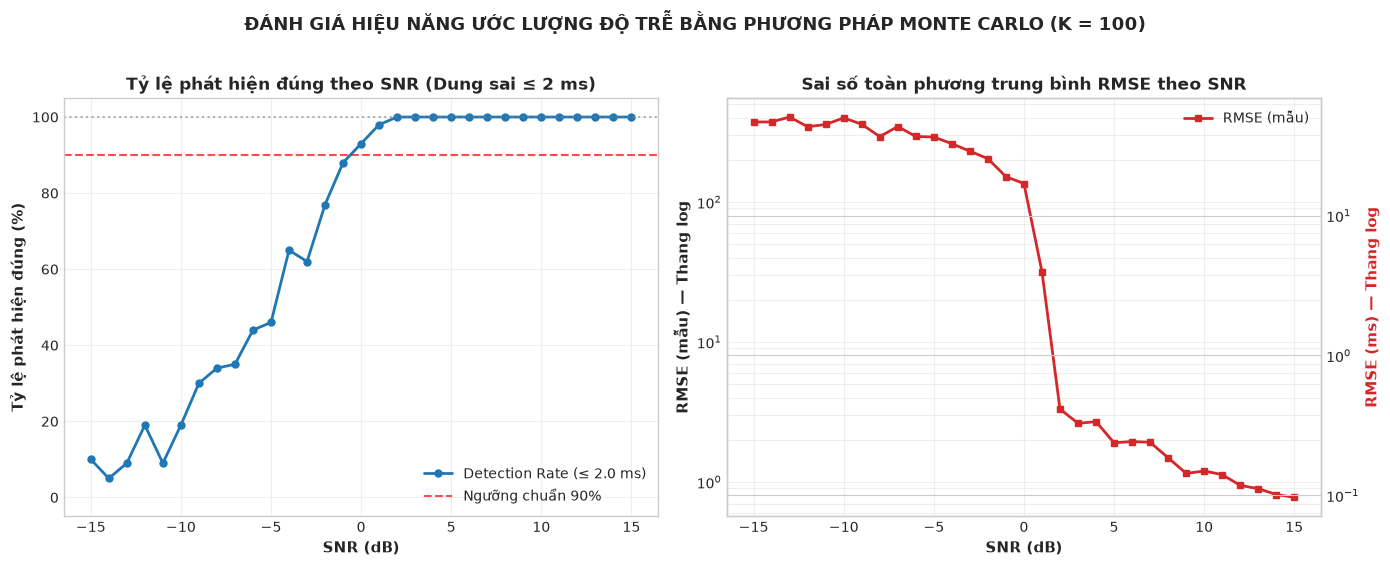

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=100)

# 1. Đồ thị Detection Rate theo SNR
ax1.plot(df_metrics['SNR_dB'], df_metrics['Detection_Rate_pct'], 'o-', color='#1f77b4', linewidth=2, markersize=5, label=f'Detection Rate (≤ {TOLERANCE_MS} ms)')
ax1.axhline(100, color='gray', linestyle=':', alpha=0.6)
ax1.axhline(90, color='red', linestyle='--', alpha=0.7, label='Ngưỡng chuẩn 90%')
ax1.set_xlabel('SNR (dB)', fontweight='bold')
ax1.set_ylabel('Tỷ lệ phát hiện đúng (%)', fontweight='bold')
ax1.set_title('Tỷ lệ phát hiện đúng theo SNR (Dung sai ≤ 2 ms)', fontweight='bold')
ax1.set_ylim(-5, 105)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# 2. Đồ thị RMSE theo SNR
ax2.semilogy(df_metrics['SNR_dB'], df_metrics['RMSE_samples'], 's-', color='#d62728', linewidth=2, markersize=5, label='RMSE (mẫu)')
ax2.set_xlabel('SNR (dB)', fontweight='bold')
ax2.set_ylabel('RMSE (mẫu) — Thang log', fontweight='bold')
ax2.set_title('Sai số toàn phương trung bình RMSE theo SNR', fontweight='bold')
ax2.grid(True, which='both', alpha=0.3)

# Trục phụ cho RMSE tính bằng ms
ax2_ms = ax2.twinx()
ax2_ms.set_ylim(ax2.get_ylim()[0] * 1000 / FS, ax2.get_ylim()[1] * 1000 / FS)
ax2_ms.set_ylabel('RMSE (ms) — Thang log', color='#d62728', fontweight='bold')
ax2_ms.set_yscale('log')

ax2.legend(loc='upper right')

plt.suptitle('ĐÁNH GIÁ HIỆU NĂNG ƯỚC LƯỢNG ĐỘ TRỄ BẰNG PHƯƠNG PHÁP MONTE CARLO (K = 100)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 📝 Nhận xét kết quả mô phỏng

- **Quy luật chung:** Khi SNR tăng, tỷ lệ phát hiện đúng tăng và RMSE giảm rõ rệt.
- **Hiện tượng sụp đổ ngưỡng (Threshold Breakdown tại SNR cực thấp $\le -10\text{ dB}$):** Nhiễu lấn át hoàn toàn tín hiệu khiến vị trí đỉnh cực đại xuất hiện ngẫu nhiên (phân bố đều) trên toàn bộ không gian tìm kiếm $[0, N-1]$. Hiện tượng đỉnh giả ngoại lai (outliers) này khiến RMSE bùng nổ lên mức $\approx 370 - 400\text{ mẫu}$, hoàn toàn phù hợp với giá trị kỳ vọng lý thuyết của phân bố đều.
- **Vùng hoạt động hiệu quả ($\text{SNR} \ge 2\text{ dB}$):** Đỉnh tương quan tại độ trễ thực $D = 200$ nổi bật hoàn toàn so với nhiễu nền. Tỷ lệ phát hiện đúng đạt $100\%$ (trong dung sai $\le 2.0\text{ ms}$) và RMSE giảm sâu xuống dưới $2\text{ mẫu}$ ($\approx 0.25\text{ ms}$).


In [23]:
print('=' * 75)
print('  KẾT QUẢ ĐÁNH GIÁ TỔNG HỢP HIỆU NĂNG MONTE CARLO (K = 100 LẦN THỬ)')
print('=' * 75)

# Hiển thị các mốc SNR tiêu biểu
key_snrs = [-15, -10, -5, 0, 5, 10, 15]
df_key = df_metrics[df_metrics['SNR_dB'].isin(key_snrs)].copy()
df_key.columns = ['SNR (dB)', 'Detection Rate (%)', 'RMSE (mẫu)', 'RMSE (ms)']
print(df_key.to_string(index=False))
print('=' * 75)

# In toàn bộ bảng số liệu 31 mức SNR
print('\nBẢNG SỐ LIỆU CHI TIẾT 31 MỨC SNR:')
df_display = df_metrics.copy()
df_display.columns = ['SNR (dB)', 'Tỷ lệ phát hiện (%)', 'RMSE (mẫu)', 'RMSE (ms)']
print(df_display.to_string(index=False))


  KẾT QUẢ ĐÁNH GIÁ TỔNG HỢP HIỆU NĂNG MONTE CARLO (K = 100 LẦN THỬ)
 SNR (dB)  Detection Rate (%)  RMSE (mẫu)  RMSE (ms)
      -15                10.0  372.885867  46.610733
      -10                19.0  399.078213  49.884777
       -5                46.0  291.252863  36.406608
        0                93.0  135.455934  16.931992
        5               100.0    1.902630   0.237829
       10               100.0    1.195826   0.149478
       15               100.0    0.774597   0.096825

BẢNG SỐ LIỆU CHI TIẾT 31 MỨC SNR:
 SNR (dB)  Tỷ lệ phát hiện (%)  RMSE (mẫu)  RMSE (ms)
      -15                 10.0  372.885867  46.610733
      -14                  5.0  373.328046  46.666006
      -13                  9.0  404.625148  50.578143
      -12                 19.0  344.671728  43.083966
      -11                  9.0  358.045137  44.755642
      -10                 19.0  399.078213  49.884777
       -9                 30.0  359.141783  44.892723
       -8                 34.0  293.06808

In [24]:
os.makedirs('results', exist_ok=True)
csv_path = os.path.join('results', 'metrics.csv')
df_metrics.to_csv(csv_path, index=False)
print(f'✓ Đã lưu bảng kết quả chỉ tiêu hiệu năng vào: {csv_path}')


✓ Đã lưu bảng kết quả chỉ tiêu hiệu năng vào: results\metrics.csv
